In [11]:
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
import geopandas as gpd

fixedline = gpd.read_file(
    "fixedline/nbn_coverage_fixedline.shp"
)

print(fixedline.head())
print(fixedline.columns)
print(fixedline.crs)

  polygon_id                                           geometry
0    3MOO-22  POLYGON ((144.42028 -38.1786, 144.42024 -38.17...
1    4SRW-63  POLYGON ((152.98842 -27.51775, 152.98744 -27.5...
2    3NAW-62  POLYGON ((145.31401 -38.02208, 145.3137 -38.02...
3    2LID-03  POLYGON ((151.03546 -33.8687, 151.03472 -33.86...
4    2MDW-21  POLYGON ((151.89023 -32.74489, 151.88942 -32.7...
Index(['polygon_id', 'geometry'], dtype='str')
EPSG:4283


In [4]:
wireless = gpd.read_file(
    "wireless/nbn_coverage_wireless.shp"
)

print(wireless.head())
print(wireless.columns)
print(wireless.crs)

   Polygon_id                                           geometry
0      100001  POLYGON ((114.52956 -28.46738, 114.52955 -28.4...
1      100002  POLYGON ((114.53148 -28.46363, 114.53148 -28.4...
2      100003  POLYGON ((114.53331 -28.4642, 114.5333 -28.464...
3      100004  POLYGON ((114.54298 -28.46095, 114.54297 -28.4...
4      100005  POLYGON ((114.55632 -28.47562, 114.55632 -28.4...
Index(['Polygon_id', 'geometry'], dtype='str')
EPSG:4283


In [5]:
nt = gpd.read_file(
    "nt/nt_lga.shp"
)

print(nt.head())
print(nt.columns)
print(nt.crs)

        LG_PLY_PID          LGA_PID  DT_CREATE                   LGA_NAME  \
0  lgp3sQkcJPLqqCJ  lgaS9n9ukxb2J06 2024-11-12  Groote Archipelago Region   
1  lgpKVd0jaGopdqO  lgaS9n9ukxb2J06 2024-11-12  Groote Archipelago Region   
2  lgpgzYlzrS_kCoR  lgaS9n9ukxb2J06 2024-11-12  Groote Archipelago Region   
3  lgp42ecd6ccde93  lga66d4787a28c4 2021-08-10           West Daly Region   
4  lgpd91e9a9da70e  lga1bed9266d38b 2021-08-10         East Arnhem Region   

             ABB_NAME STATE                                           geometry  
0  Groote Archipelago    NT  POLYGON ((136.5969 -13.6771, 136.59712 -13.676...  
1  Groote Archipelago    NT  POLYGON ((136.6007 -13.67166, 136.60058 -13.67...  
2  Groote Archipelago    NT  POLYGON ((136.59107 -13.67503, 136.59234 -13.6...  
3           West Daly    NT  POLYGON ((129.65575 -14.73461, 129.65631 -14.7...  
4         East Arnhem    NT  POLYGON ((136.47401 -11.44916, 136.47621 -11.4...  
Index(['LG_PLY_PID', 'LGA_PID', 'DT_CREATE', 'LGA_N

<Axes: >

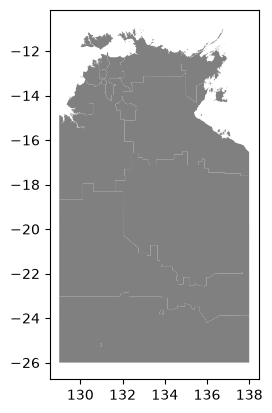

In [11]:
nt.plot(color='gray')

<Axes: >

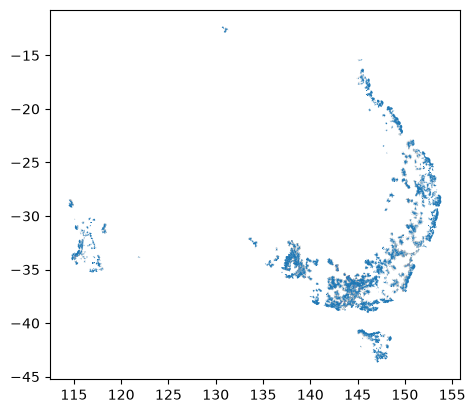

In [6]:
wireless.plot()

<Axes: >

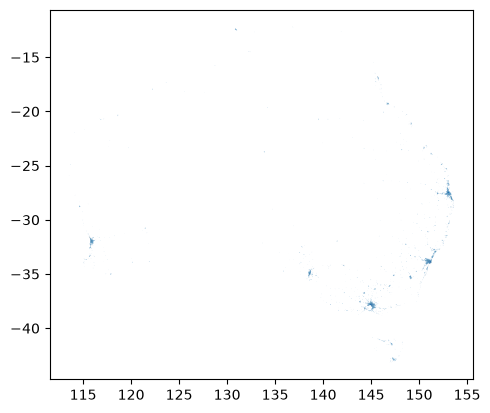

In [5]:
fixedline.plot()

In [7]:
nt_fixedline = gpd.clip(fixedline, nt)
nt_wireless = gpd.clip(wireless, nt)

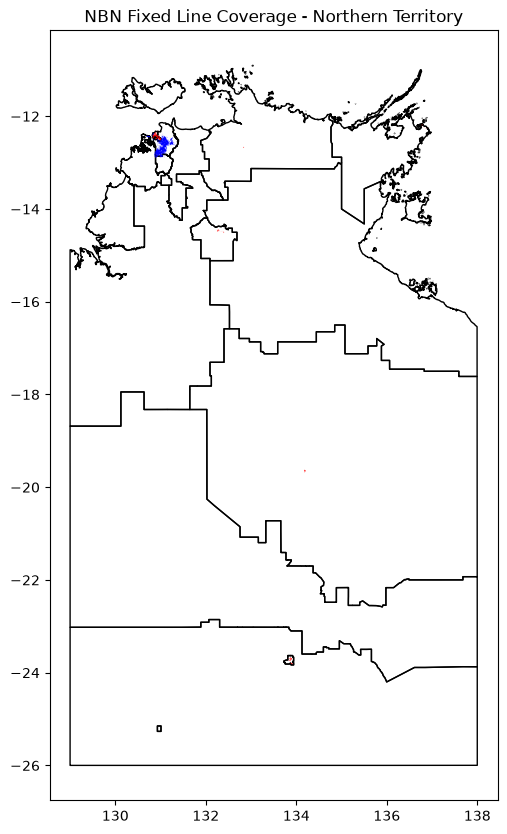

In [ ]:
fig, ax = plt.subplots(figsize=(8, 10))

# NT boundary
nt.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1
)

# NBN Fixed Line
nt_fixedline.plot(
    ax=ax,
    color='red'
)

# NBN Wireless Line
nt_wireless.plot(
    ax=ax,
    color='blue'
)

plt.title("NBN Fixed Line Coverage - Northern Territory")

plt.show()

In [8]:
nt_fixedline = nt_fixedline.to_crs(fixedline.crs)
nt_wireless = nt_wireless.to_crs(fixedline.crs)
nt_communities = nt.to_crs(nt.crs)

In [9]:
nt_fixedline["connection"] = "Fixed Line"
nt_wireless["connection"] = "Fixed Wireless"

In [12]:
coverage = pd.concat([
    nt_fixedline,
    nt_wireless
], ignore_index=True)

coverage = gpd.GeoDataFrame(
    coverage,
    geometry="geometry",
    crs=fixedline.crs
)

In [14]:
community_connection = gpd.sjoin(
    nt_communities,
    coverage[["connection", "geometry"]],
    how="left",
    predicate="intersects"
)

In [19]:
community_connection.to_csv('test.csv', index=False)

In [ ]:
result = (
    community_connection
    .groupby("ABB_NAME")["connection"]
    .apply(
        lambda x: ", ".join(sorted(set(x.dropna())))
        if x.notna().any()
        else "No mapped coverage"
    )
    .reset_index()
)

result.to_csv(
    "community_nbn_connection.csv",
    index=False
)


,ABB_NAME,connection
0,Alice Springs,Fixed Line
1,Barkly,Fixed Line
2,Belyuen,No mapped coverage
3,Central Desert,No mapped coverage
4,Coomalie,Fixed Wireless


In [20]:
result

,ABB_NAME,connection
0,Alice Springs,Fixed Line
1,Barkly,Fixed Line
2,Belyuen,No mapped coverage
3,Central Desert,No mapped coverage
4,Coomalie,Fixed Wireless
5,Darwin,"Fixed Line, Fixed Wireless"
6,Darwin Waterfront Precinct,"Fixed Line, Fixed Wireless"
7,East Arnhem,Fixed Line
8,Groote Archipelago,No mapped coverage
9,Katherine,Fixed Line


Merge

In [56]:
communities = pd.read_csv(
    "community_connectivity_master_table.csv"
)

communities_gdf = gpd.GeoDataFrame(
    communities,
    geometry=gpd.points_from_xy(
        communities["community_longitude"],
        communities["community_latitude"]
    ),
    crs="EPSG:4326"
)

# Convert community points to the same CRS as NBN
communities_gdf = communities_gdf.to_crs(nt_wireless.crs)

print("Community CRS:", communities_gdf.crs)
print("Wireless CRS:", nt_wireless.crs)

Community CRS: EPSG:4283
Wireless CRS: EPSG:4283


Fixedline coverage

In [57]:
fixedline_join = gpd.sjoin(
    communities_gdf,
    nt_fixedline[["polygon_id", "geometry"]],
    how="left",
    predicate="within"
)

fixedline_ids = set(
    fixedline_join.loc[
        fixedline_join["polygon_id"].notna(),
        "community_id"
    ]
)

communities_gdf["nbn_fixed_line"] = (
    communities_gdf["community_id"]
    .isin(fixedline_ids)
    .map({True: "Yes", False: "No"})
)

Wireless coverage

In [58]:
wireless_join = gpd.sjoin(
    communities_gdf,
    nt_wireless[["Polygon_id", "geometry"]],
    how="left",
    predicate="within"
)

wireless_ids = set(
    wireless_join.loc[
        wireless_join["Polygon_id"].notna(),
        "community_id"
    ]
)

communities_gdf["nbn_fixed_wireless"] = (
    communities_gdf["community_id"]
    .isin(wireless_ids)
    .map({True: "Yes", False: "No"})
)

In [59]:
print(
    wireless_join["Polygon_id"]
    .notna()
    .value_counts()
)

Polygon_id
False    791
True       1
Name: count, dtype: int64


In [60]:
def get_nbn_connection(row):
    fixed = row["nbn_fixed_line"] == "Yes"
    wireless = row["nbn_fixed_wireless"] == "Yes"

    if fixed and wireless:
        return "Fixed Line + Fixed Wireless"
    elif fixed:
        return "Fixed Line"
    elif wireless:
        return "Fixed Wireless"
    else:
        return "No mapped NBN coverage"

communities_gdf["nbn_connection"] = communities_gdf.apply(
    get_nbn_connection,
    axis=1
)

In [61]:
communities_gdf[
    [
        "community_name",
        "community_latitude",
        "community_longitude",
        "nbn_fixed_line",
        "nbn_fixed_wireless",
        "nbn_connection"
    ]
].head(20)

,community_name,community_latitude,community_longitude,nbn_fixed_line,nbn_fixed_wireless,nbn_connection
0,10 MILE,-20.40628,134.75934,No,No,No mapped NBN coverage
1,10 MILE OUTSTATION,-22.46667,132.37658,No,No,No mapped NBN coverage
2,16 MILE CAMP,-23.45764,133.83248,No,No,No mapped NBN coverage
3,20 MILE,-16.08535,136.54826,No,No,No mapped NBN coverage
4,4 MILE CAMP,-11.77798,130.59548,No,No,No mapped NBN coverage
5,5 MILE BORE,-23.23265,131.98296,No,No,No mapped NBN coverage
6,ACACIA LARRAKIA,-12.81420,131.17150,No,No,No mapped NBN coverage
7,ADBANAE,-11.24167,131.97531,No,No,No mapped NBN coverage
8,ADELAIDE BORE,-22.21485,133.93607,No,No,No mapped NBN coverage
9,ADELAIDE RIVER,-13.23780,131.10473,No,No,No mapped NBN coverage


In [65]:

communities_gdf[
    communities_gdf["community_name"].str.upper() == "EAST ARNHEM"
]

,community_id,community_name,community_type,community_latitude,community_longitude,population_final,nearest_tower_state,nearest_tower_id,nearest_tower_name,distance_community_to_tower_km,nearest_wifi_id,nearest_wifi_address,distance_community_to_wifi_km,geometry,nbn_fixed_line,nbn_fixed_wireless,nbn_connection


In [41]:
communities_gdf.head(20)

,community_id,community_name,community_type,community_latitude,community_longitude,population_final,nearest_tower_state,nearest_tower_id,nearest_tower_name,distance_community_to_tower_km,nearest_wifi_id,nearest_wifi_address,distance_community_to_wifi_km,geometry,nbn_fixed_line,nbn_fixed_wireless,nbn_connection
0,1022,10 MILE,Family Outstation,-20.40628,134.75934,8.0,NT,53061,Panjirriji TENNANT CREEK,28.23,4,10 LUCK STREET,147.31,POINT (134.75934 -20.40628),No,No,No mapped NBN coverage
1,1004,10 MILE OUTSTATION,Family Outstation,-22.46667,132.37658,10.0,NT,10009413,"Camp 1 Tanami Pipeline Tanami Rd, 72 km SE of ...",19.58,96,2 POSSUM CR,94.88,POINT (132.37658 -22.46667),No,No,No mapped NBN coverage
2,783,16 MILE CAMP,Family Outstation,-23.45764,133.83248,NaN,NT,10033488,"MarchNet Site Burt Plain, 18247 Stuart Highway...",2.39,107,"Town Camp name: Whitegate, (Unit 1) Lot 5126, ...",27.52,POINT (133.83248 -23.45764),No,No,No mapped NBN coverage
3,24993,20 MILE,Family Outstation,-16.08535,136.54826,6.0,NT,2231,Telstra Radio Terminal 32 km ESE of Borroloola...,13.49,19,191 ROBINSON RD,25.84,POINT (136.54826 -16.08535),No,No,No mapped NBN coverage
4,1006,4 MILE CAMP,Family Outstation,-11.77798,130.59548,7.0,NT,10003079,Airport Lighting Room Bathurst Island Airport ...,2.85,124,142 Wagait Tower Road,74.98,POINT (130.59548 -11.77798),No,No,No mapped NBN coverage
5,759,5 MILE BORE,Family Outstation,-23.23265,131.98296,24.0,NT,2877,Broadcast Site Pump House PAPUNYA,7.57,96,2 POSSUM CR,8.21,POINT (131.98296 -23.23265),No,No,No mapped NBN coverage
6,279,ACACIA LARRAKIA,Family Outstation,-12.81420,131.17150,799.0,NT,10022049,"Acacia Water Compound, Lot 13, Soob Road MANTON",0.16,10,"Bagot Community Laundry, 133 Bagot Road",56.11,POINT (131.1715 -12.8142),No,No,No mapped NBN coverage
7,979,ADBANAE,Family Outstation,-11.24167,131.97531,NaN,NT,1027,Telstra Radio Terminal Araru Point COBOURG PEN...,11.91,10,"Bagot Community Laundry, 133 Bagot Road",178.64,POINT (131.97531 -11.24167),No,No,No mapped NBN coverage
8,1,ADELAIDE BORE,Family Outstation,-22.21485,133.93607,14.0,NT,2936,Telstra Radio Terminal 6.5 km N of Casuarina B...,16.39,109,"Apungalindum Homeland School, 11780 Sandover H...",79.31,POINT (133.93607 -22.21485),No,No,No mapped NBN coverage
9,10153,ADELAIDE RIVER,Village,-13.23780,131.10473,NaN,NT,1739,Pump Station ADELAIDE RIVER,0.22,10,"Bagot Community Laundry, 133 Bagot Road",95.38,POINT (131.10473 -13.2378),No,No,No mapped NBN coverage


In [63]:
final = communities_gdf.drop(columns="geometry")

final.to_csv(
    "community_connectivity_master_table_with_nbn.csv",
    index=False
)

In [64]:
for name in communities_gdf['community_name']:
    print(name)

10 MILE
10 MILE OUTSTATION
16 MILE CAMP
20 MILE
4 MILE CAMP
5 MILE BORE
ACACIA LARRAKIA
ADBANAE
ADELAIDE BORE
ADELAIDE RIVER
ADJAMARRAGU
AKARNENEHE WELL
AKNGWERTNARRE
AKWALIRRUMANJA
ALAMIRRA
ALATYEYE
ALHARRGAN
ALI CURUNG
ALICE SPRINGS
ALICE WELL
ALKIPI
ALKNGARRIINTJA
ALKUPTIJA
ALPARA
ALPURRURULAM
ALYANGULA
ALYARPERE
ALYINGBERRMA
ALYUEN
AMANBIDJI
AMANBURNUNGA
AMANGAL INDIGENOUS VILLAGE
AMATJATPALK
AMENGERNTERNEAH
AMIRRABA
AMOONGUNA
AMPILATWATJA
AMPUTJUTA
AMUNDURNGUA
ANDANANGKI
ANGAS DOWNS
ANGATYEPE
ANGKERLE ARRENGE (A)
ANGKERLE ARRENGE (B)
ANGULA
ANGURUGU
ANGWURA
ANKABADBIRRI
ANKERRAPW
ANKWELEYELENGKWE
ANNERRE
ANNINGIE
ANTERE
ANTHELK EWLPAYE
ANTHEPE
APER ALWERRKNGE
ARARLAGU
ARARU POINT
ARAWERR
AREYONGA
ARKANTA
ARLPARRA
ARMORRAN
ARMSTRONGS
ARRAWAJIN
ARRGAMURRMUR
ARRILLHJERE
ARRKAPA
ARRUNGKEE
ARTEKERR
ARTEKERRE
ATHELEY
ATITJERE
ATJI CREEK
ATNARARA
ATNARPA
ATNELTYEY
ATNWENGERRPE
AWUMBUNYJI
BABUNGI
BADAWARRKA
BAGHETTI
BAGOT
BAJAMINYI
BALMA
BAMBOO SPRINGS
BANATJARL
BANIYALA
BANTHULA
BARDALUM